In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv('Crime_Data_from_2020_to_2024 (1).csv')

print(df.info())
display(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004894 entries, 0 to 1004893
Data columns (total 28 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   DR_NO           1004894 non-null  int64  
 1   Date Rptd       1004894 non-null  object 
 2   DATE OCC        1004894 non-null  object 
 3   TIME OCC        1004894 non-null  int64  
 4   AREA            1004894 non-null  int64  
 5   AREA NAME       1004894 non-null  object 
 6   Rpt Dist No     1004894 non-null  int64  
 7   Part 1-2        1004894 non-null  int64  
 8   Crm Cd          1004894 non-null  int64  
 9   Crm Cd Desc     1004894 non-null  object 
 10  Mocodes         853296 non-null   object 
 11  Vict Age        1004894 non-null  int64  
 12  Vict Sex        860263 non-null   object 
 13  Vict Descent    860251 non-null   object 
 14  Premis Cd       1004878 non-null  float64
 15  Premis Desc     1004306 non-null  object 
 16  Weapon Used Cd  327216 non-null   fl

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,...,Status,Status Desc,Crm Cd 1,Crm Cd 2,Crm Cd 3,Crm Cd 4,LOCATION,Cross Street,LAT,LON
0,211507896,04/11/2021 12:00:00 AM,11/07/2020 12:00:00 AM,845,15,N Hollywood,1502,2,354,THEFT OF IDENTITY,...,IC,Invest Cont,354.0,NaN,NaN,NaN,7800 BEEMAN AV,NaN,34.2124,-118.4092
1,201516622,10/21/2020 12:00:00 AM,10/18/2020 12:00:00 AM,1845,15,N Hollywood,1521,1,230,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",...,IC,Invest Cont,230.0,NaN,NaN,NaN,ATOLL AV,N GAULT,34.1993,-118.4203
2,240913563,12/10/2024 12:00:00 AM,10/30/2020 12:00:00 AM,1240,9,Van Nuys,933,2,354,THEFT OF IDENTITY,...,IC,Invest Cont,354.0,NaN,NaN,NaN,14600 SYLVAN ST,NaN,34.1847,-118.4509
3,210704711,12/24/2020 12:00:00 AM,12/24/2020 12:00:00 AM,1310,7,Wilshire,782,1,331,THEFT FROM MOTOR VEHICLE - GRAND ($950.01 AND ...,...,IC,Invest Cont,331.0,NaN,NaN,NaN,6000 COMEY AV,NaN,34.0339,-118.3747
4,201418201,10/03/2020 12:00:00 AM,09/29/2020 12:00:00 AM,1830,14,Pacific,1454,1,420,THEFT FROM MOTOR VEHICLE - PETTY ($950 & UNDER),...,IC,Invest Cont,420.0,NaN,NaN,NaN,4700 LA VILLA MARINA,NaN,33.9813,-118.4350


C:\Users\HP\AppData\Local\Temp\ipykernel_23416\2879550534.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Year', palette='viridis')


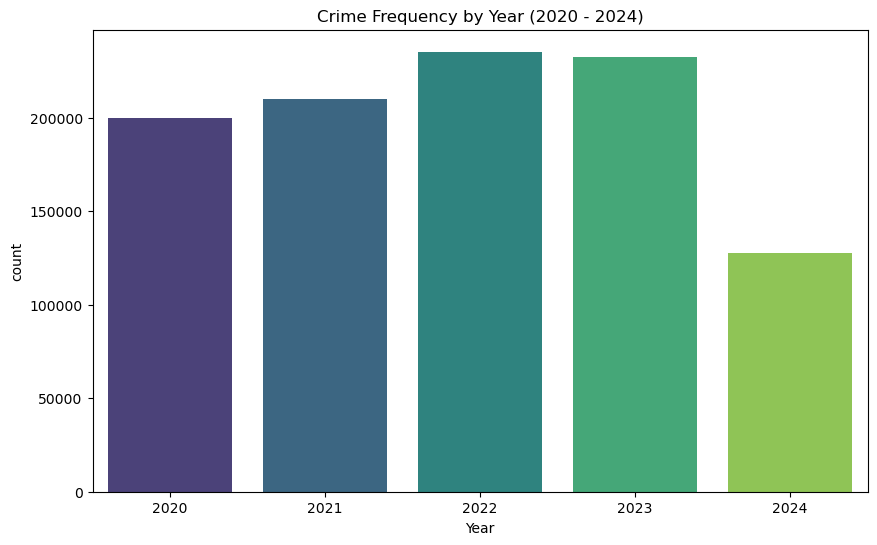

In [8]:

df['DATE OCC'] = pd.to_datetime(df['DATE OCC'])

df['Year'] = df['DATE OCC'].dt.year
df['Month'] = df['DATE OCC'].dt.month

df['Hour'] = df['TIME OCC'] // 100

df['Vict Sex'] = df['Vict Sex'].fillna('Unknown')
df.dropna(subset=['LAT', 'LON'], inplace=True) # Essential for geospatial plots
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Year', palette='viridis')
plt.title('Crime Frequency by Year (2020 - 2024)')
plt.show()

In [11]:
import pandas as pd

df = pd.read_csv('Crime_Data_from_2020_to_2024 (1).csv')

cols_to_drop = ['DR_NO', 'AREA', 'Part 1-2', 'Crm Cd 1', 'Crm Cd 2', 'Crm Cd 3', 'Crm Cd 4', 'Cross Street']
df.drop(columns=[c for c in cols_to_drop if c in df.columns], inplace=True)

def get_time_group(time):
    
    hour = time // 100
    if 6 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 18:
        return 'Afternoon'
    elif 18 <= hour < 24:
        return 'Evening'
    else:
        return 'Night'


df['Time_Category'] = df['TIME OCC'].apply(get_time_group)


time_groups = {
    'Morning': 'crime_morning_6_12am.csv',
    'Afternoon': 'crime_afternoon_12_6pm.csv',
    'Evening': 'crime_evening_6_12pm.csv',
    'Night': 'crime_night_12_6am.csv'
}

for group_name, filename in time_groups.items():
    subset = df[df['Time_Category'] == group_name]
    subset.to_csv(filename, index=False)
    print(f"Saved {group_name} data to {filename} ({len(subset)} rows)")

Saved Morning data to crime_morning_6_12am.csv (209893 rows)
Saved Afternoon data to crime_afternoon_12_6pm.csv (327261 rows)
Saved Evening data to crime_evening_6_12pm.csv (314065 rows)
Saved Night data to crime_night_12_6am.csv (153675 rows)


C:\Users\HP\AppData\Local\Temp\ipykernel_23416\954594902.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=gender_counts.index, y=gender_counts.values, palette='viridis')


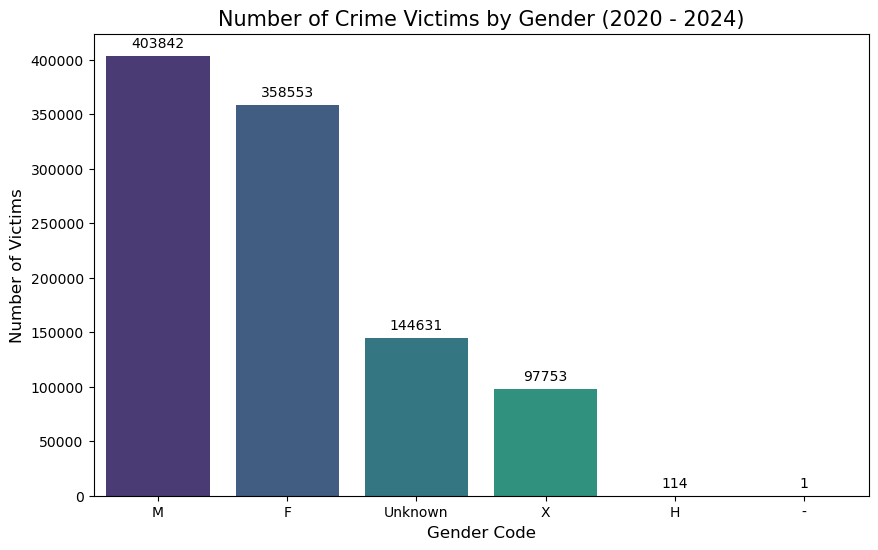

Gender Distribution counts:
Vict Sex
M          403842
F          358553
Unknown    144631
X           97753
H             114
-               1
Name: count, dtype: int64


In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

file_path = 'Crime_Data_from_2020_to_2024 (1).csv'
df = pd.read_csv(file_path)


df['Vict Sex'] = df['Vict Sex'].fillna('Unknown')


gender_counts = df['Vict Sex'].value_counts()


plt.figure(figsize=(10, 6))
sns.barplot(x=gender_counts.index, y=gender_counts.values, palette='viridis')


plt.title('Number of Crime Victims by Gender (2020 - 2024)', fontsize=15)
plt.xlabel('Gender Code', fontsize=12)
plt.ylabel('Number of Victims', fontsize=12)


for i, count in enumerate(gender_counts.values):
    plt.text(i, count + 5000, str(count), ha='center', va='bottom', fontsize=10)


plt.savefig('victim_gender_distribution.png')
plt.show()

print("Gender Distribution counts:")
print(gender_counts)

In [18]:
import pandas as pd

file_path = 'Crime_Data_from_2020_to_2024 (1).csv'
df = pd.read_csv(file_path)

print("--- Missing Values BEFORE Cleaning ---")
print(df.isnull().sum()[df.isnull().sum() > 0]) # Only show columns with missing values

if 'Vict Sex' in df.columns:
    df['Vict Sex'] = df['Vict Sex'].fillna('X')
if 'Vict Descent' in df.columns:
    df['Vict Descent'] = df['Vict Descent'].fillna('X')

if 'Weapon Desc' in df.columns:
    df['Weapon Desc'] = df['Weapon Desc'].fillna('Unknown')
if 'Weapon Used Cd' in df.columns:
    df['Weapon Used Cd'] = df['Weapon Used Cd'].fillna(0)
    
if 'Premis Desc' in df.columns:
    df['Premis Desc'] = df['Premis Desc'].fillna('Unknown')

for col in ['Crm Cd 1', 'Crm Cd 2', 'Crm Cd 3', 'Crm Cd 4']:
    if col in df.columns:
        df[col] = df[col].fillna(0)

if 'Mocodes' in df.columns:
    df['Mocodes'] = df['Mocodes'].fillna('None')

if 'Cross Street' in df.columns:
    df['Cross Street'] = df['Cross Street'].fillna('Not Reported')

for col in df.columns:
    if df[col].isnull().any():
        if pd.api.types.is_numeric_dtype(df[col]):
            df[col] = df[col].fillna(0)
        else:
            df[col] = df[col].fillna('Unknown')


print("\n--- Missing Values AFTER Cleaning ---")
print(df.isnull().sum())


output_filename = 'Crime_Data_No_Nulls.csv'
df.to_csv(output_filename, index=False)
print(f"\nCleaned dataset saved to {output_filename}")

--- Missing Values BEFORE Cleaning ---
Mocodes            151598
Vict Sex           144631
Vict Descent       144643
Premis Cd              16
Premis Desc           588
Weapon Used Cd     677678
Weapon Desc        677678
Status                  1
Crm Cd 1               11
Crm Cd 2           935740
Crm Cd 3          1002580
Crm Cd 4          1004830
Cross Street       850666
dtype: int64

--- Missing Values AFTER Cleaning ---
DR_NO             0
Date Rptd         0
DATE OCC          0
TIME OCC          0
AREA              0
AREA NAME         0
Rpt Dist No       0
Part 1-2          0
Crm Cd            0
Crm Cd Desc       0
Mocodes           0
Vict Age          0
Vict Sex          0
Vict Descent      0
Premis Cd         0
Premis Desc       0
Weapon Used Cd    0
Weapon Desc       0
Status            0
Status Desc       0
Crm Cd 1          0
Crm Cd 2          0
Crm Cd 3          0
Crm Cd 4          0
LOCATION          0
Cross Street      0
LAT               0
LON               0
dtype: int6

In [28]:
import pandas as pd


file_path = 'Crime_Data_No_Nulls.csv'
df = pd.read_csv(file_path)


if 'DR_NO' in df.columns:
    df.drop(columns=['DR_NO'], inplace=True)
    print("Dropped 'DR_NO' column.")


if 'DATE OCC' in df.columns:
  
    df['DATE OCC'] = pd.to_datetime(df['DATE OCC']).dt.date
    print("Converted 'DATE OCC' to date-only format.")


if 'Date Rptd' in df.columns:
    df['Date Rptd'] = pd.to_datetime(df['Date Rptd']).dt.date
    print("Converted 'Date Rptd' to date-only format.")


df.to_csv(file_path, index=False)
print(f"Successfully updated and saved {file_path}!")


display(df[['DATE OCC', 'TIME OCC']].head())

Dropped 'DR_NO' column.


C:\Users\HP\AppData\Local\Temp\ipykernel_23416\1146048787.py:15: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['DATE OCC'] = pd.to_datetime(df['DATE OCC']).dt.date


Converted 'DATE OCC' to date-only format.


C:\Users\HP\AppData\Local\Temp\ipykernel_23416\1146048787.py:20: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date Rptd'] = pd.to_datetime(df['Date Rptd']).dt.date


Converted 'Date Rptd' to date-only format.
Successfully updated and saved Crime_Data_No_Nulls.csv!


,DATE OCC,TIME OCC
0,2020-11-07,845
1,2020-10-18,1845
2,2020-10-30,1240
3,2020-12-24,1310
4,2020-09-29,1830


In [35]:
import pandas as pd

file_path = 'Crime_Data_No_Nulls.csv'
df = pd.read_csv(file_path)

df['DATE OCC'] = pd.to_datetime(df['DATE OCC'])

df['Day_of_Week'] = df['DATE OCC'].dt.day_name()

df['Is_Weekend'] = df['Day_of_Week'].isin(['Saturday', 'Sunday']).astype(int)


df.to_csv(file_path, index=False)

print("Successfully added 'Day_of_Week' and 'Is_Weekend' columns!")


display(df[['DATE OCC', 'Day_of_Week', 'Is_Weekend']].head(10))

Successfully added 'Day_of_Week' and 'Is_Weekend' columns!


,DATE OCC,Day_of_Week,Is_Weekend
0,2020-11-07,Saturday,1
1,2020-10-18,Sunday,1
2,2020-10-30,Friday,0
3,2020-12-24,Thursday,0
4,2020-09-29,Tuesday,0
5,2020-11-11,Wednesday,0
6,2020-04-16,Thursday,0
7,2020-07-07,Tuesday,0
8,2020-03-02,Monday,0
9,2020-09-01,Tuesday,0


In [40]:
import pandas as pd


file_path = 'Crime_Data_No_Nulls.csv'
df = pd.read_csv(file_path)

def categorize_premise(premise):
    if pd.isna(premise):
        return 'Unknown'
    
    prem = str(premise).upper()
    
    if any(word in prem for word in ['DWELLING', 'APARTMENT', 'HOME', 'RESIDENCE', 'HOUSE']):
        return 'Residential'
    elif any(word in prem for word in ['STORE', 'MARKET', 'BANK', 'RESTAURANT', 'SHOP', 'HOTEL', 'BUSINESS', 'MALL']):
        return 'Commercial'
    elif any(word in prem for word in ['STREET', 'SIDEWALK', 'ALLEY', 'PARK', 'LOT', 'DRIVEWAY']):
        return 'Public/Street'
    elif any(word in prem for word in ['BUS', 'TRAIN', 'STATION', 'VEHICLE', 'TRANSIT', 'TERMINAL', 'DEPOT']):
        return 'Transit'
    else:
        return 'Other/Unknown'

def categorize_severity_by_desc(description):
    if pd.isna(description):
        return 'Unknown'
        
    desc = str(description).lower()
    
   
    severe_keywords = ['homicide', 'murder', 'rape', 'robbery', 'aggravated', 
                       'kidnapping', 'arson', 'deadly weapon', 'firearm', 'manslaughter']
    
    medium_keywords = ['burglary', 'theft', 'stolen', 'vandalism', 'fraud', 'forgery',
                       'simple assault', 'battery', 'narcotics', 'drugs', 'extortion']
    
    if any(keyword in desc for keyword in severe_keywords):
        return 'Severe'
    elif any(keyword in desc for keyword in medium_keywords):
        return 'Medium'
    else:
        return 'Low'


df['Premise_Category'] = df['Premis Desc'].apply(categorize_premise)
df['Crime_Severity_Desc'] = df['Crm Cd Desc'].apply(categorize_severity_by_desc)


output_filename = 'Crime_Data_Premise_Severity.csv'
df.to_csv(output_filename, index=False)

print(f"Successfully processed and saved to {output_filename}!")


print("\n--- Premise Category Counts ---")
print(df['Premise_Category'].value_counts())

print("\n--- Crime Severity (By Desc) Counts ---")
print(df['Crime_Severity_Desc'].value_counts())

Successfully processed and saved to Crime_Data_Premise_Severity.csv!

--- Premise Category Counts ---
Premise_Category
Public/Street    412304
Residential      302255
Commercial       130120
Other/Unknown    116248
Transit           43967
Name: count, dtype: int64

--- Crime Severity (By Desc) Counts ---
Crime_Severity_Desc
Medium    765573
Low       122289
Severe    117032
Name: count, dtype: int64
